In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [5]:
# E-Commerce Sales Analysis

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [10]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [13]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [14]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [15]:
df.duplicated().sum()

np.int64(5268)

In [16]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
## Initial Data Quality Assessment

In [19]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,-41.40
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-39.60
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,-25.50


In [20]:
df[df["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [21]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,2.95
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,2.95
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom,3.75
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom,2.10
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom,7.50


In [22]:
df.loc[517]

InvoiceNo                           536409
StockCode                            21866
Description    UNION JACK FLAG LUGGAGE TAG
Quantity                                 1
InvoiceDate            2010-12-01 11:45:00
UnitPrice                             1.25
CustomerID                         17908.0
Country                     United Kingdom
Revenue                               1.25
Name: 517, dtype: object

In [23]:
df[df.duplicated()].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25


In [24]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,-41.40
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-39.60
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,-25.50


In [25]:
df[df["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [26]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,2.95
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,2.95
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom,3.75
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom,2.10
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom,7.50


In [27]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [28]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [29]:
df[df["CustomerID"].isna()].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,0.00
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,3.32
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom,14.94
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,5.02
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom,4.30
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom,3.87
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom,4.73


In [30]:
df[df["UnitPrice"] == 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [31]:
df_clean = df.copy()

In [32]:
df["Revenue"].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [33]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [34]:
df_clean = df.copy()

In [35]:
df_clean = df_clean[df_clean["Revenue"] != 0]

In [36]:
### Analysing Revenue


In [37]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [38]:
df.sort_values("Revenue", ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00


In [39]:
df.sort_values("Revenue").head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,-38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom,-17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom,-16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom,-16453.71
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom,-13541.33
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom,-13541.33
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom,-13474.79
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom,-11586.50


In [40]:
df["Revenue"].sum()

np.float64(9747747.934)

In [41]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

In [42]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [43]:
country_revenue.sum()

np.float64(9747747.934)

In [44]:
country_revenue["United Kingdom"] / country_revenue.sum()

np.float64(0.8399690286862109)

In [45]:
#### Revenue per Transaction


In [46]:
country_summary = (
    df.groupby("Country")
      .agg(
          Revenue=("Revenue", "sum"),
          Transactions=("InvoiceNo", "count")
      )
)

country_summary["Revenue_per_Transaction"] = (
    country_summary["Revenue"] /
    country_summary["Transactions"]
)

country_summary.sort_values(
    "Revenue_per_Transaction",
    ascending=False
).head(10)

,Revenue,Transactions,Revenue_per_Transaction
Country,,,
Netherlands,284661.54,2371,120.059696
Australia,137077.27,1259,108.877895
Japan,35340.62,358,98.716816
Sweden,36595.91,462,79.211926
Denmark,18768.14,389,48.247147
Lithuania,1661.06,35,47.458857
Singapore,9120.39,229,39.827031
Lebanon,1693.88,45,37.641778
Brazil,1143.60,32,35.737500


In [47]:
# Verifying whether this is due to large orders.

In [48]:
country_quantity = (
    df.groupby("Country")["Quantity"]
      .mean()
      .sort_values(ascending=False)
)

country_quantity.head(10)

Country
Netherlands       84.406580
Sweden            77.136364
Japan             70.441341
Australia         66.444003
Singapore         22.855895
Denmark           21.048843
Czech Republic    19.733333
Lithuania         18.628571
Canada            18.298013
Norway            17.722836
Name: Quantity, dtype: float64

In [49]:
### Revenue over Time.
#This shows how revenue changes over time.

In [50]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
)

monthly_revenue

InvoiceDate
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64

<Axes: xlabel='InvoiceDate'>

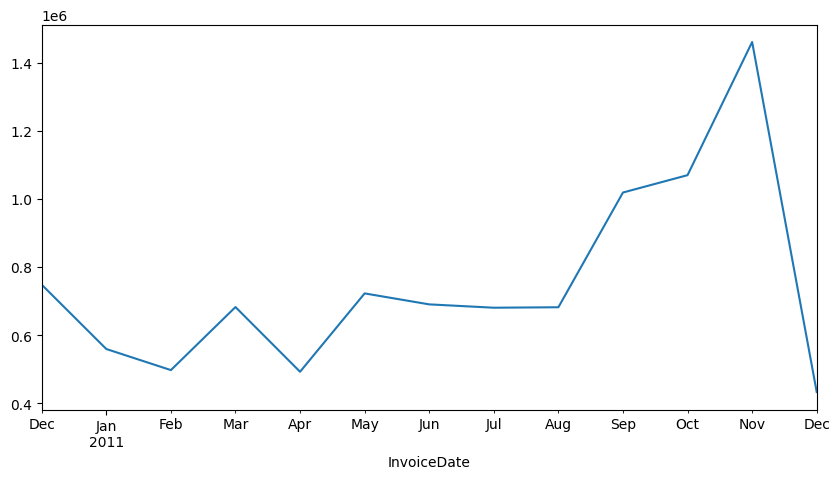

In [51]:
monthly_revenue.plot(figsize=(10,5))

In [52]:
country_quantity = (
    df.groupby("Country")["Quantity"]
      .mean()
      .sort_values(ascending=False)
)

country_quantity.head(10)

Country
Netherlands       84.406580
Sweden            77.136364
Japan             70.441341
Australia         66.444003
Singapore         22.855895
Denmark           21.048843
Czech Republic    19.733333
Lithuania         18.628571
Canada            18.298013
Norway            17.722836
Name: Quantity, dtype: float64

In [53]:
### Top products by revenue

In [54]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_products.head(15)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
BLACK RECORD COVER FRAME               40596.96
PICNIC BASKET WICKER 60 PIECES         39619.50
SET OF 3 CAKE TINS PANTRY DESIGN       37413.44
Name: Revenue, dtype: float64

In [55]:
### Top products by Quantity sold

In [56]:
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_quantity.head(15)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
VICTORIAN GLASS HANGING T-LIGHT       23854
ASSORTED COLOURS SILK FAN             23082
BROCADE RING PURSE                    23053
RED  HARMONICA IN BOX                 21866
JUMBO BAG PINK POLKADOT               21009
Name: Quantity, dtype: int64

In [57]:
# Useful check including accounting entries

In [58]:
df_products = df[
    ~df["Description"].isin(
        ["AMAZON FEE", "POSTAGE", "Manual", "Adjust bad debt", "DOTCOM POSTAGE"]
    )
]

In [59]:
top_products = (
    df_products.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_products.head(15)

Description
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
BLACK RECORD COVER FRAME               40596.96
PICNIC BASKET WICKER 60 PIECES         39619.50
SET OF 3 CAKE TINS PANTRY DESIGN       37413.44
DOORMAT KEEP CALM AND COME IN          36565.39
JAM MAKING SET WITH JARS               36116.09
Name: Revenue, dtype: float64

In [60]:
#### Customer Analysis


In [61]:
df_customers = df[df["CustomerID"].notna()].copy()

In [62]:
top_customers = (
    df_customers.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_customers.head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

In [63]:
df_customers["CustomerID"].nunique()

4372

In [64]:
top_customers.head(10).sum()

np.float64(1369181.7900000003)

In [65]:
df_customers["Revenue"].sum()

np.float64(8300065.813999999)

In [66]:
### Customer Concentration (Pareto Analysis)


In [67]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [68]:
df_customers = df[df["CustomerID"].notna()].copy()

In [69]:
customer_revenue = (
    df_customers.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head()

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
Name: Revenue, dtype: float64

In [70]:
top_1pct = int(len(customer_revenue) * 0.01)

customer_revenue.head(top_1pct).sum() / customer_revenue.sum()

np.float64(0.2971308873045522)

In [71]:
top_5pct = int(len(customer_revenue) * 0.05)

customer_revenue.head(top_5pct).sum() / customer_revenue.sum()

np.float64(0.48522875001868027)

In [72]:
top_10pct = int(len(customer_revenue) * 0.10)

customer_revenue.head(top_10pct).sum() / customer_revenue.sum()

np.float64(0.600069320125032)

In [73]:
### Investigate Customer 14646


In [74]:
df_customers[
    df_customers["CustomerID"] == 14646
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
37952,539491,21981,PACK OF 12 WOODLAND TISSUES,12,2010-12-20 10:09:00,0.29,14646.0,Netherlands,3.48
37953,539491,21986,PACK OF 12 PINK POLKADOT TISSUES,12,2010-12-20 10:09:00,0.29,14646.0,Netherlands,3.48
37954,539491,22720,SET OF 3 CAKE TINS PANTRY DESIGN,2,2010-12-20 10:09:00,4.95,14646.0,Netherlands,9.90
37955,539491,21931,JUMBO STORAGE BAG SUKI,1,2010-12-20 10:09:00,1.95,14646.0,Netherlands,1.95
37956,539491,22613,PACK OF 20 SPACEBOY NAPKINS,2,2010-12-20 10:09:00,0.85,14646.0,Netherlands,1.70
37957,539491,20751,FUNKY WASHING UP GLOVES ASSORTED,1,2010-12-20 10:09:00,2.10,14646.0,Netherlands,2.10
37958,539491,21246,RED RETROSPOT BIG BOWL,2,2010-12-20 10:09:00,4.95,14646.0,Netherlands,9.90
37959,539491,22960,JAM MAKING SET WITH JARS,1,2010-12-20 10:09:00,4.25,14646.0,Netherlands,4.25
37960,539491,22355,CHARLOTTE BAG SUKI DESIGN,2,2010-12-20 10:09:00,0.85,14646.0,Netherlands,1.70
37961,539491,21123,SET/10 IVORY POLKADOT PARTY CANDLES,2,2010-12-20 10:09:00,1.25,14646.0,Netherlands,2.50


In [75]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

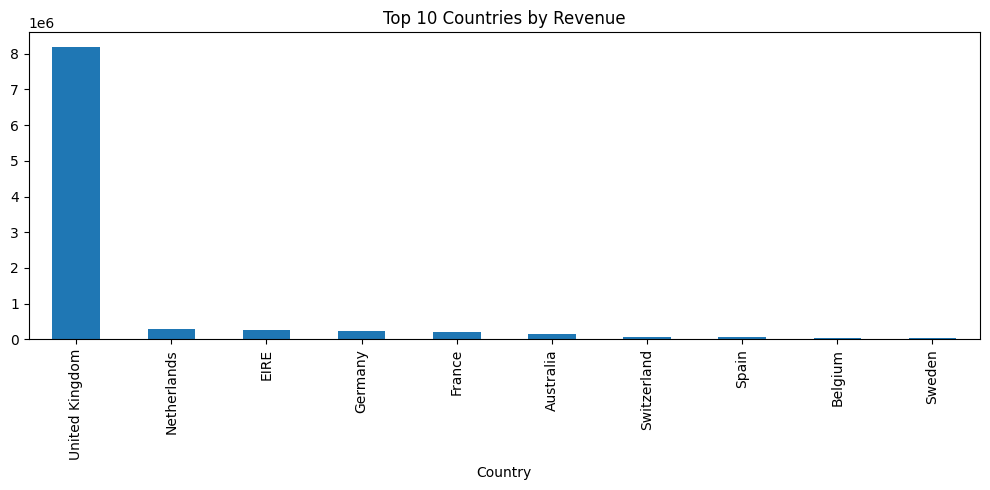

In [95]:
country_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Countries by Revenue"
)

plt.tight_layout()
plt.savefig("../visuals/top_10_countries_by_revenue.png")
plt.show()

In [96]:
import matplotlib.pyplot as plt

In [78]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
)

monthly_revenue

InvoiceDate
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64

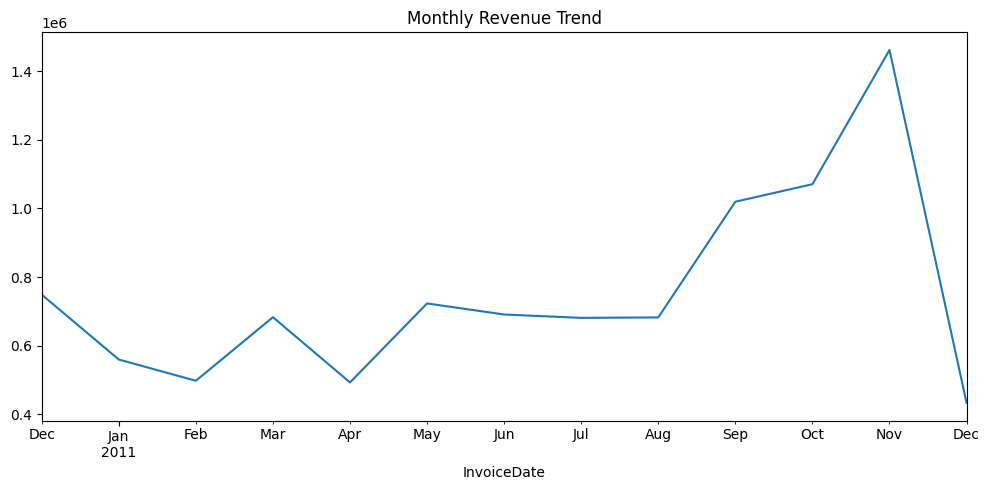

In [92]:
monthly_revenue.plot(
    figsize=(10,5),
    title="Monthly Revenue Trend"
)

plt.tight_layout()
plt.savefig("../visuals/Monthly Revenue Trend.png")
plt.show()

In [80]:
df_products = df[
    ~df["Description"].isin(
        ["AMAZON FEE", "POSTAGE", "Manual", "Adjust bad debt", "DOTCOM POSTAGE"]
    )
]

In [81]:
top_products = (
    df_products.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_products.head(15)

Description
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
BLACK RECORD COVER FRAME               40596.96
PICNIC BASKET WICKER 60 PIECES         39619.50
SET OF 3 CAKE TINS PANTRY DESIGN       37413.44
DOORMAT KEEP CALM AND COME IN          36565.39
JAM MAKING SET WITH JARS               36116.09
Name: Revenue, dtype: float64

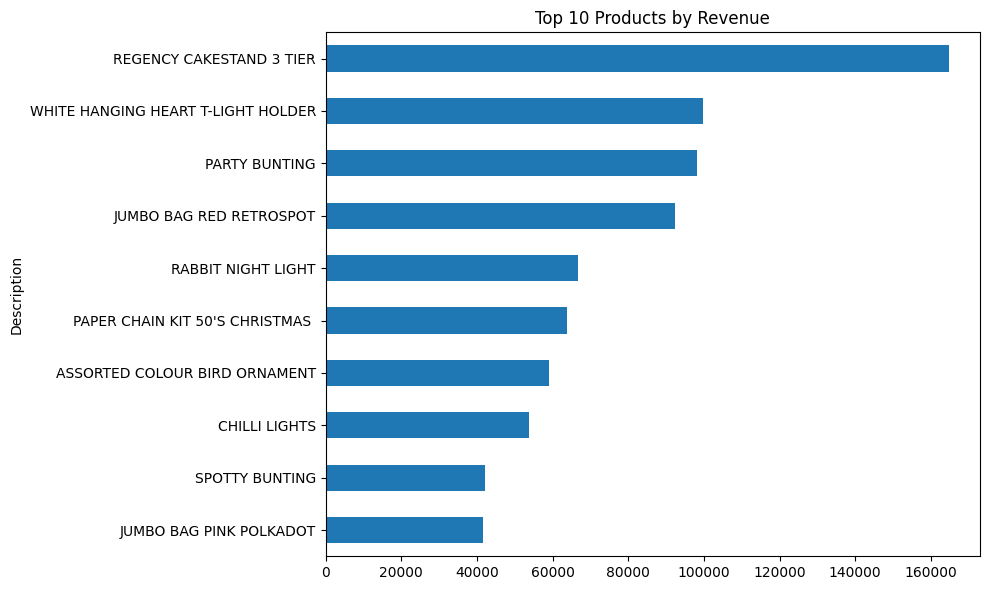

In [93]:
top_products.head(10).sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Top 10 Products by Revenue"
)

plt.tight_layout()
plt.savefig("../visuals/Top 10 Products by Revenue.png")
plt.show()

In [83]:
## Customer concentration charts.


In [84]:
customer_revenue_sorted = (
    customer_revenue
    .reset_index(drop=True)
)

In [85]:
cumulative_share = (
    customer_revenue_sorted.cumsum()
    / customer_revenue_sorted.sum()
)

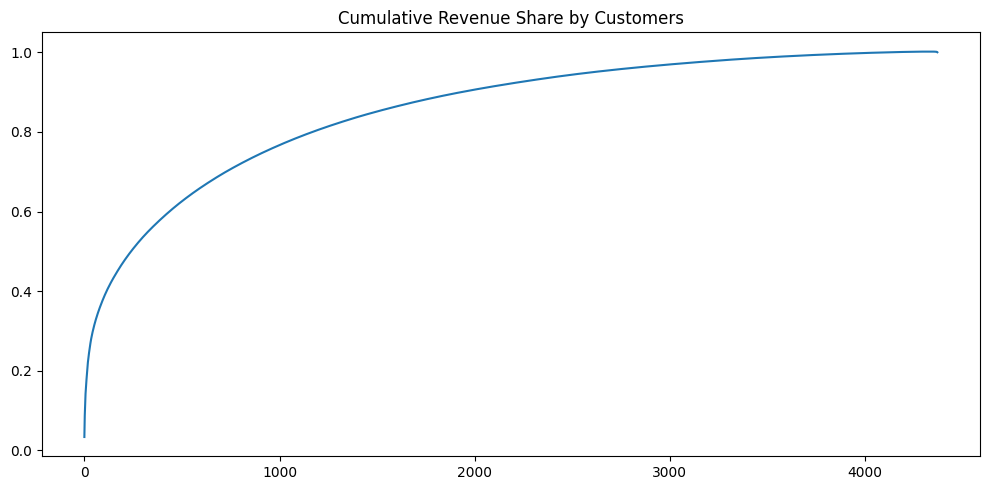

In [94]:
cumulative_share.plot(
    figsize=(10,5),
    title="Cumulative Revenue Share by Customers"
)

plt.tight_layout()
plt.savefig("../visuals/Cumulative Revenue Share by Customers.png")
plt.show()